In [1]:
import random, warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
from pathlib import Path

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
class Config:
    # ── Data files (same folder mein rakhna) ──
    DATA_FILES = [
        'data1.xlsx',
        'data2.xlsx',
        'data3.xlsx',
    ]

    # Q-learning hyperparameters (paper: α=0.001, γ=0.9)
    ALPHA   = 0.1    # Learning rate
    GAMMA   = 0.9    # Discount factor
    EPSILON = 0.2    # Exploration rate (ε-greedy)
    EPISODES = 60    # Training episodes per user request

    # Reward weights — paper Section 5.1 (AHP method)
    # θ=0.30 (bandwidth), β=0.15 (delay), λ=0.18 (BER), ω=0.37 (visible time)
    THETA  = 0.30
    BETA   = 0.15
    LAMBDA = 0.18
    OMEGA  = 0.37

    # Synthetic link properties (xlsx has only 0/1 topology)
    BW_RANGE    = (10, 100)    # Mbps
    DELAY_RANGE = (5,  50)     # ms
    BER_RANGE   = (1e-8, 5e-7) # Bit Error Rate
    VTIME_RANGE = (1.0, 4.0)   # minutes (visible time)
    NUM_USERS   = 20           # users to simulate per time-slice

print("✅ Configuration set!")
print(f"   α={Config.ALPHA}, γ={Config.GAMMA}, ε={Config.EPSILON}, Episodes={Config.EPISODES}")
print(f"   Weights: θ={Config.THETA}, β={Config.BETA}, λ={Config.LAMBDA}, ω={Config.OMEGA}")

✅ Configuration set!
   α=0.1, γ=0.9, ε=0.2, Episodes=60
   Weights: θ=0.3, β=0.15, λ=0.18, ω=0.37


In [3]:
def load_topology(filepath):
    """Load xlsx adjacency matrix → NetworkX graph with synthetic link attributes."""
    df = pd.read_excel(filepath, index_col=0)
    df = df.fillna(0)
    satellites = list(df.columns)

    G = nx.Graph()
    G.add_nodes_from(range(len(satellites)))

    for i, src in enumerate(satellites):
        for j, dst in enumerate(satellites):
            if i < j and df.loc[src, dst] == 1:
                G.add_edge(i, j,
                    bw      = random.uniform(*Config.BW_RANGE),
                    delay   = random.uniform(*Config.DELAY_RANGE),
                    ber     = random.uniform(*Config.BER_RANGE),
                    vtime   = random.uniform(*Config.VTIME_RANGE),
                    capacity= random.uniform(50, 200),
                    load    = 0.0)
    return G, satellites

# Load all 3 time slices
graphs = {}
for f in Config.DATA_FILES:
    G, sats = load_topology(f)
    name = Path(f).stem
    graphs[name] = G
    print(f"✅ {f} → {G.number_of_nodes()} satellites, {G.number_of_edges()} links")

✅ data1.xlsx → 66 satellites, 466 links
✅ data2.xlsx → 66 satellites, 494 links
✅ data3.xlsx → 66 satellites, 490 links


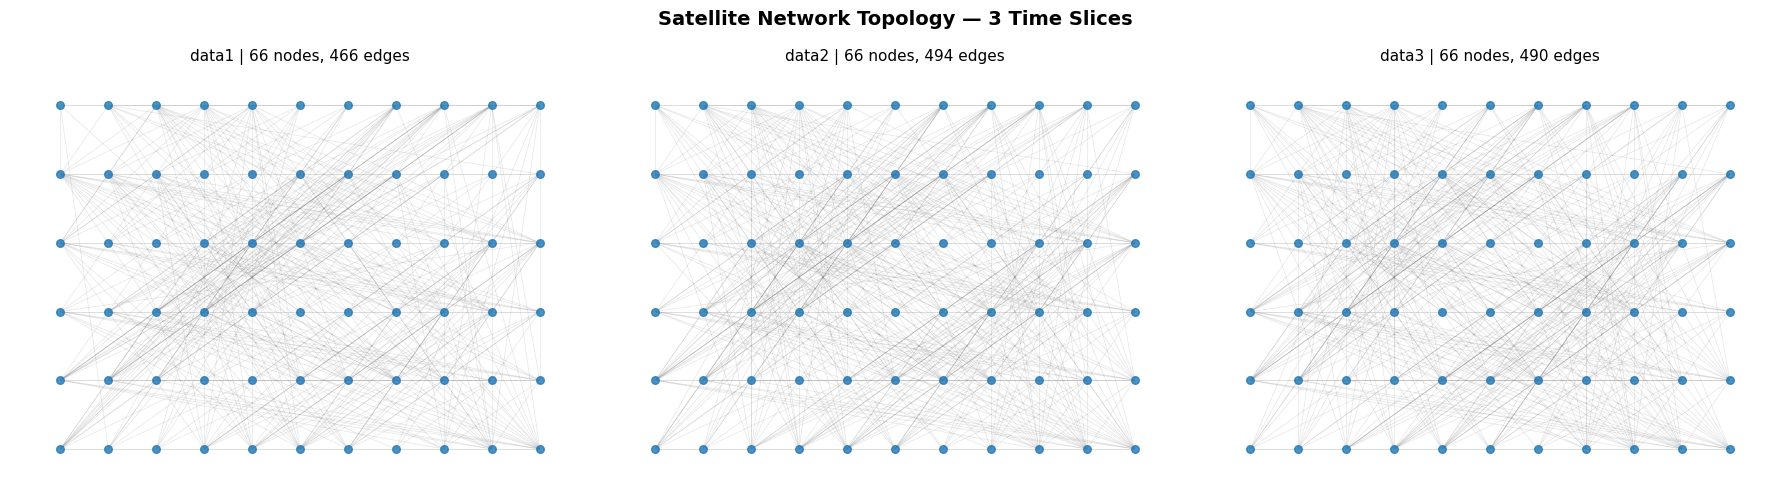

✅ Topology saved as satellite_topology.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Satellite Network Topology — 3 Time Slices', fontsize=14, fontweight='bold')

for ax, (name, G) in zip(axes, graphs.items()):
    # Layout: each satellite gets a position based on orbit (row) and seat (col)
    pos = {}
    n = G.number_of_nodes()
    cols = 11  # satellites per orbit
    for node in G.nodes():
        row = node // cols
        col = node % cols
        pos[node] = (col, -row)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=30, node_color='#1f77b4', alpha=0.8)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, edge_color='gray', width=0.5)
    ax.set_title(f'{name} | {G.number_of_nodes()} nodes, {G.number_of_edges()} edges', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('satellite_topology.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Topology saved as satellite_topology.png")

In [6]:
#Step-5 : Reward Function

def get_global_stats(G):
    """Collect min/max of each link attribute across entire graph for normalisation."""
    bws, delays, bers, vtimes = [], [], [], []
    for u, v, d in G.edges(data=True):
        bws.append(d['bw']); delays.append(d['delay'])
        bers.append(d['ber']); vtimes.append(d['vtime'])
    return {
        'bw':    (min(bws),    max(bws)),
        'delay': (min(delays), max(delays)),
        'ber':   (min(bers),   max(bers)),
        'vtime': (min(vtimes), max(vtimes)),
    }

def compute_link_reward(G, u, v, gs):
    """Compute reward for selecting link (u,v) — Paper Equations 18-22."""
    d = G[u][v]
    eps = 1e-10
    r_bw    = (d['bw']    - gs['bw'][0])    / (gs['bw'][1]    - gs['bw'][0]    + eps)
    r_delay = (gs['delay'][1] - d['delay']) / (gs['delay'][1]  - gs['delay'][0] + eps)  # inverted
    r_ber   = (gs['ber'][1]   - d['ber']  ) / (gs['ber'][1]    - gs['ber'][0]   + eps)  # inverted
    r_vtime = (d['vtime'] - gs['vtime'][0]) / (gs['vtime'][1]  - gs['vtime'][0] + eps)
    return Config.THETA*r_bw + Config.BETA*r_delay + Config.LAMBDA*r_ber + Config.OMEGA*r_vtime

print("✅ Reward function defined!")
print(f"   Formula: r = {Config.THETA}·r(bw) + {Config.BETA}·r(delay) + {Config.LAMBDA}·r(BER) + {Config.OMEGA}·r(vtime)")

✅ Reward function defined!
   Formula: r = 0.3·r(bw) + 0.15·r(delay) + 0.18·r(BER) + 0.37·r(vtime)


In [7]:
def path_checking_algorithm(G, start, end):
    """Algorithm 1 from paper — BFS reachability check."""
    if start == end:
        return True
    visited = {start}
    queue   = deque([start])
    while queue:
        node = queue.popleft()
        for nbr in G.neighbors(node):
            if nbr == end:
                return True
            if nbr not in visited:
                visited.add(nbr)
                queue.append(nbr)
    return False

# Quick test
G_test = graphs['data1']
print("Path checking test:")
print(f"  Node 0 → Node 10 reachable? {path_checking_algorithm(G_test, 0, 10)}")
print(f"  Node 0 → Node 0  reachable? {path_checking_algorithm(G_test, 0, 0)}")
print("✅ Path Checking Algorithm (PCA) ready!")

Path checking test:
  Node 0 → Node 10 reachable? True
  Node 0 → Node 0  reachable? True
✅ Path Checking Algorithm (PCA) ready!


In [8]:
def qlra(G, start, end, gs, episodes=Config.EPISODES):
    """Algorithm 2 from paper — Q-Learning Routing Algorithm (QLRA)."""
    Q = {}  # sparse Q-table: {(state, action): value}

    def get_q(s, a): return Q.get((s, a), 0.0)
    def set_q(s, a, v): Q[(s, a)] = v

    reward_history = []

    for episode in range(episodes):
        current, visited = start, {start}
        ep_reward, path  = 0, [start]

        while current != end:
            neighbours = list(G.neighbors(current))
            if not neighbours: break

            # ε-greedy action selection (Equation 27)
            if random.random() < Config.EPSILON:
                action = random.choice(neighbours)
            else:
                action = max(neighbours, key=lambda n: get_q(current, n))

            # Avoid revisit (basic loop prevention)
            if action in visited and len(neighbours) > 1:
                others = [n for n in neighbours if n not in visited]
                if others: action = random.choice(others)

            # Reward (Equations 18-22) + terminal bonus (Equation 28)
            r = compute_link_reward(G, current, action, gs)
            if action == end: r += 1.0
            ep_reward += r

            # Bellman Q-update (Equation 26)
            next_nbrs  = list(G.neighbors(action))
            max_next_q = max([get_q(action, n) for n in next_nbrs], default=0.0)
            old_q = get_q(current, action)
            set_q(current, action, old_q + Config.ALPHA*(r + Config.GAMMA*max_next_q - old_q))

            visited.add(action); path.append(action); current = action
            if current == end or len(path) > G.number_of_nodes(): break

        reward_history.append(ep_reward)

    return extract_path(G, Q, start, end), Q, reward_history

print("✅ QLRA defined!")

✅ QLRA defined!


In [9]:
def sqlra(G, start, end, gs, episodes=Config.EPISODES):
    """Algorithm 3 from paper — Speed-Up Q-Learning Routing Algorithm (SQLRA)."""
    Q = {}
    def get_q(s, a): return Q.get((s, a), 0.0)
    def set_q(s, a, v): Q[(s, a)] = v

    # BFS from end_node → get back-to-front traversal order (Figure 6 & 7)
    def bfs_from_end(end_node):
        order, visited = [], {end_node}
        queue = deque([end_node])
        while queue:
            node = queue.popleft()
            order.append(node)
            for nbr in G.neighbors(node):
                if nbr not in visited:
                    visited.add(nbr); queue.append(nbr)
        return list(reversed(order))   # reversed = back-to-front

    nodes_list    = bfs_from_end(end)
    reward_history = []

    for episode in range(episodes):
        ep_reward = 0
        # Update Q for all nodes in back-to-front order (Figure 7)
        for node in nodes_list:
            if node == end: continue
            for nbr in G.neighbors(node):
                r = compute_link_reward(G, node, nbr, gs)
                if nbr == end: r += 1.0
                max_next_q = max([get_q(nbr, n) for n in G.neighbors(nbr)], default=0.0)
                old_q = get_q(node, nbr)
                set_q(node, nbr, old_q + Config.ALPHA*(r + Config.GAMMA*max_next_q - old_q))
                ep_reward += r
        reward_history.append(ep_reward)

    return extract_path(G, Q, start, end), Q, reward_history

def extract_path(G, Q, start, end):
    """Greedy path extraction from converged Q-table (Equation 25)."""
    path, current, visited = [start], start, {start}
    while current != end and len(path) <= G.number_of_nodes():
        neighbours = [n for n in G.neighbors(current) if n not in visited]
        if not neighbours:
            neighbours = list(G.neighbors(current))
            if not neighbours: break
        current = max(neighbours, key=lambda n: Q.get((current, n), 0.0))
        path.append(current); visited.add(current)
    return path if path[-1] == end else None

print("✅ SQLRA defined!")

✅ SQLRA defined!


In [10]:
def dijkstra_routing(G, start, end):
    """Shortest path using hop count — OSPF-like baseline."""
    try:
        return nx.shortest_path(G, source=start, target=end)
    except nx.NetworkXNoPath:
        return None

def evaluate_path(G, path):
    """Compute path metrics — Paper Equations 7-10."""
    if path is None or len(path) < 2: return None
    bws, delays, bers, vtimes = [], [], [], []
    for i in range(len(path)-1):
        u, v = path[i], path[i+1]
        if not G.has_edge(u, v): return None
        d = G[u][v]
        bws.append(d['bw']); delays.append(d['delay'])
        bers.append(d['ber']); vtimes.append(d['vtime'])
    return {
        'throughput': np.mean(bws),          # Eq.7  avg bandwidth
        'delay':      np.sum(delays),         # Eq.8  total delay
        'ber':        np.sum(bers) * 1e7,     # Eq.9  total BER ×10⁻⁷
        'vtime':      np.min(vtimes),          # Eq.10 min visible time
        'hops':       len(path) - 1,
    }

print("✅ Dijkstra & path evaluator defined!")

✅ Dijkstra & path evaluator defined!


Running convergence experiment on data1...


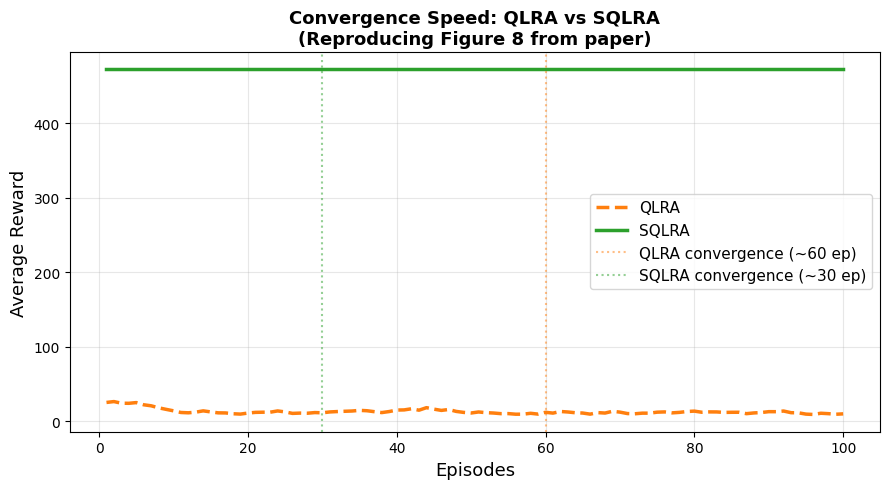

✅ Convergence plot saved!
   SQLRA final reward: 472.62
   QLRA  final reward: 9.81


In [11]:
def smooth(data, weight=0.8):
    last, out = data[0], []
    for x in data:
        s = last*weight + (1-weight)*x
        out.append(s); last = s
    return out

print("Running convergence experiment on data1...")
G_c  = graphs['data1']
gs_c = get_global_stats(G_c)
nodes = list(G_c.nodes())

# Pick a valid src-dst pair
src, dst = 0, 33
while not path_checking_algorithm(G_c, src, dst):
    src, dst = random.sample(nodes, 2)

_, _, qlra_rewards  = qlra( G_c, src, dst, gs_c, episodes=100)
_, _, sqlra_rewards = sqlra(G_c, src, dst, gs_c, episodes=100)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
eps_x = list(range(1, 101))
ax.plot(eps_x, smooth(qlra_rewards),  '--', color='#ff7f0e', linewidth=2.5, label='QLRA')
ax.plot(eps_x, smooth(sqlra_rewards), '-',  color='#2ca02c', linewidth=2.5, label='SQLRA')
ax.axvline(x=60, color='#ff7f0e', linestyle=':', alpha=0.5, label='QLRA convergence (~60 ep)')
ax.axvline(x=30, color='#2ca02c', linestyle=':', alpha=0.5, label='SQLRA convergence (~30 ep)')
ax.set_xlabel('Episodes', fontsize=13)
ax.set_ylabel('Average Reward', fontsize=13)
ax.set_title('Convergence Speed: QLRA vs SQLRA\n(Reproducing Figure 8 from paper)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convergence_speed.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Convergence plot saved!")
print(f"   SQLRA final reward: {smooth(sqlra_rewards)[-1]:.2f}")
print(f"   QLRA  final reward: {smooth(qlra_rewards)[-1]:.2f}")

In [12]:
def simulate_time_slice(G, slice_name, num_users=Config.NUM_USERS):
    stats = {alg: {'throughput':[], 'delay':[], 'ber':[], 'vtime':[], 'success':0}
             for alg in ['dijkstra', 'qlra', 'sqlra']}
    gs    = get_global_stats(G)
    nodes = list(G.nodes())

    print(f"\n{'='*56}")
    print(f"  Time Slice: {slice_name}  | Satellites: {G.number_of_nodes()} | Links: {G.number_of_edges()}")
    print(f"{'='*56}")
    print(f"  {'User':>4}  {'Src→Dst':>10}  {'Dijkstra':>10}  {'QLRA':>10}  {'SQLRA':>10}")
    print(f"  {'-'*52}")

    for uid in range(1, num_users+1):
        src, dst = random.sample(nodes, 2)
        if not path_checking_algorithm(G, src, dst): continue

        d_path = dijkstra_routing(G, src, dst)
        q_path, _, _ = qlra( G, src, dst, gs)
        s_path, _, _ = sqlra(G, src, dst, gs)

        def fmt(m): return f"{m['throughput']:6.1f}Mb" if m else "  FAIL  "
        dm = evaluate_path(G, d_path)
        qm = evaluate_path(G, q_path)
        sm = evaluate_path(G, s_path)

        print(f"  {uid:>4}  {src:>4}→{dst:<5}  {fmt(dm):>10}  {fmt(qm):>10}  {fmt(sm):>10}")

        for alg, metrics in [('dijkstra',dm),('qlra',qm),('sqlra',sm)]:
            if metrics:
                for k in ['throughput','delay','ber','vtime']:
                    stats[alg][k].append(metrics[k])
                stats[alg]['success'] += 1
    return stats

all_stats = {}
for name, G in graphs.items():
    all_stats[name] = simulate_time_slice(G, name)

print("\n✅ Simulation complete!")


  Time Slice: data1  | Satellites: 66 | Links: 466
  User     Src→Dst    Dijkstra        QLRA       SQLRA
  ----------------------------------------------------
     1     2→61         30.2Mb      59.9Mb      74.0Mb
     2    19→42         64.1Mb      64.8Mb      75.3Mb
     3     9→13         83.2Mb      50.1Mb      74.4Mb
     4    23→13         46.9Mb      75.8Mb      77.8Mb
     5    14→16         67.0Mb      66.1Mb      78.8Mb
     6    46→42         72.5Mb      57.2Mb      FAIL  
     7    40→18         48.2Mb      60.1Mb      FAIL  
     8    59→29         66.0Mb      64.7Mb      75.5Mb
     9    20→17         80.3Mb      62.8Mb      75.0Mb
    10    47→45         11.4Mb      40.1Mb      FAIL  
    11    20→58         28.9Mb      57.2Mb      73.9Mb
    12    54→62         62.6Mb      57.2Mb      FAIL  
    13    48→18         45.2Mb      60.2Mb      76.9Mb
    14    36→53         65.6Mb      65.4Mb      FAIL  
    15    43→19         81.1Mb      51.0Mb      74.8Mb
    16    63→

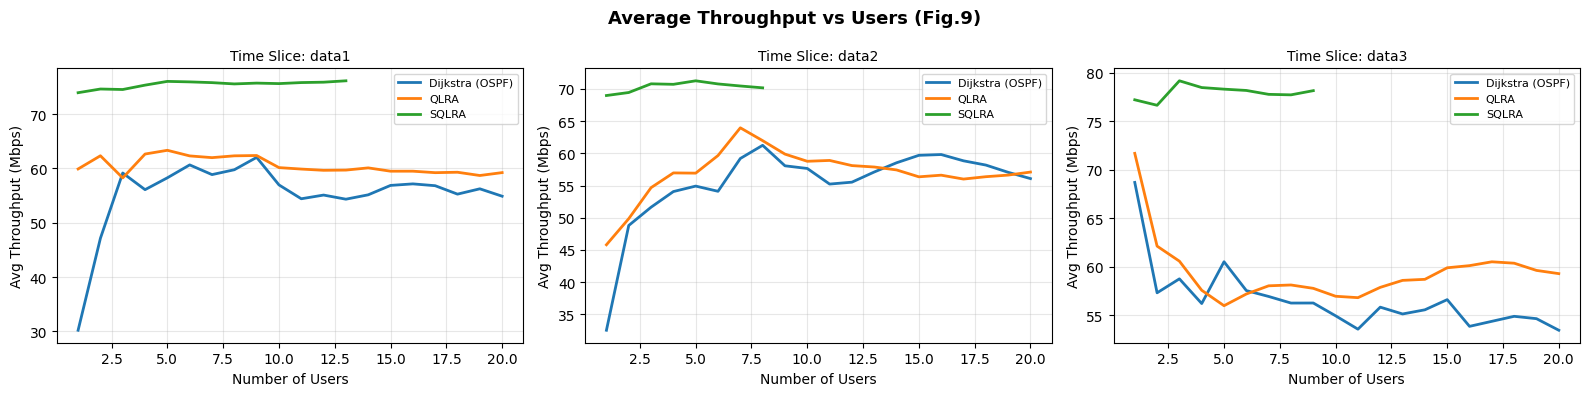

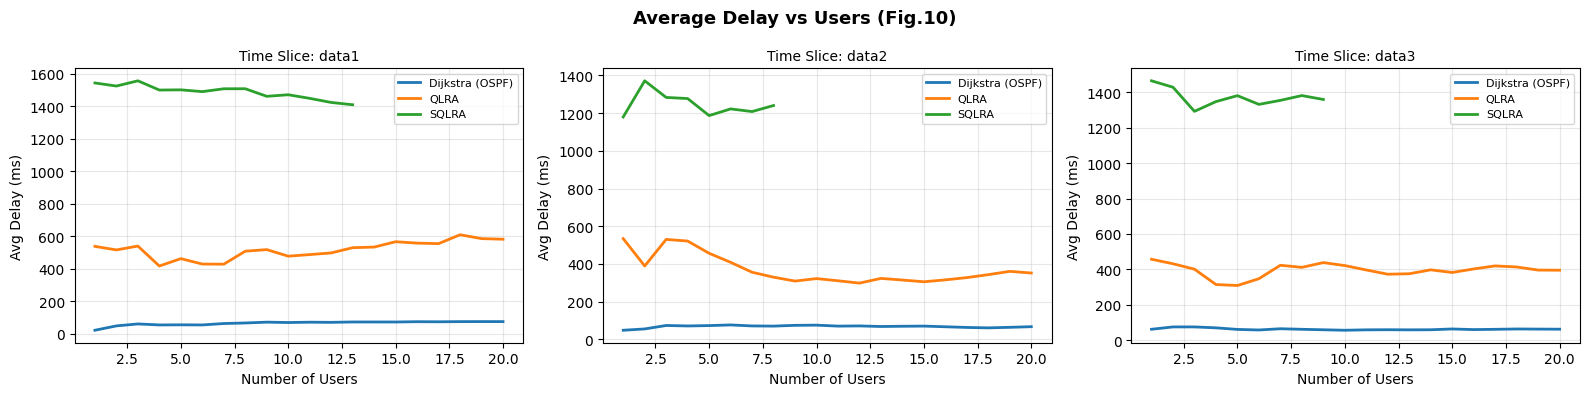

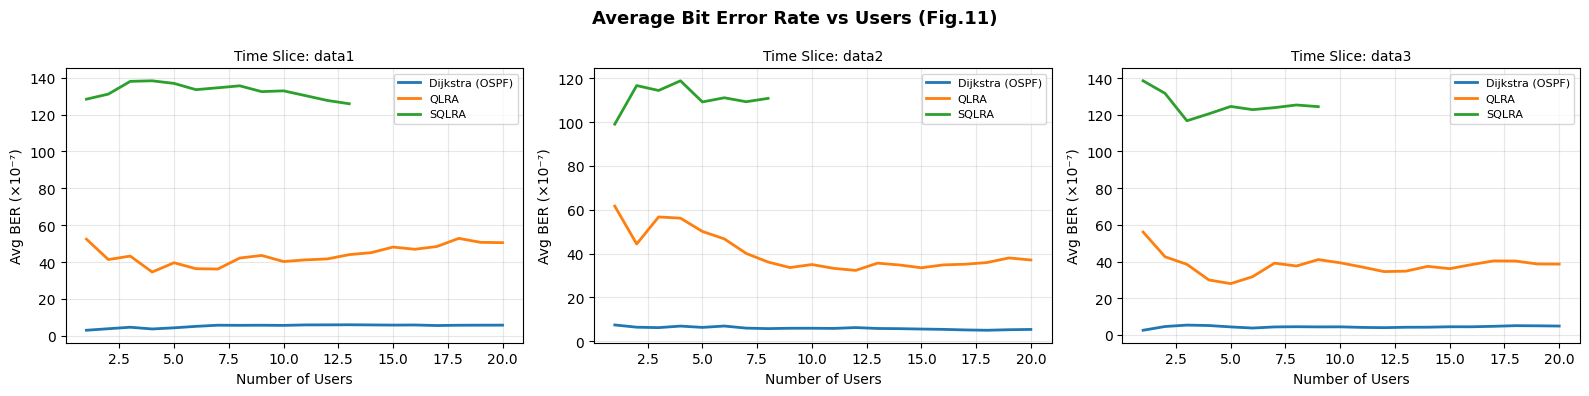

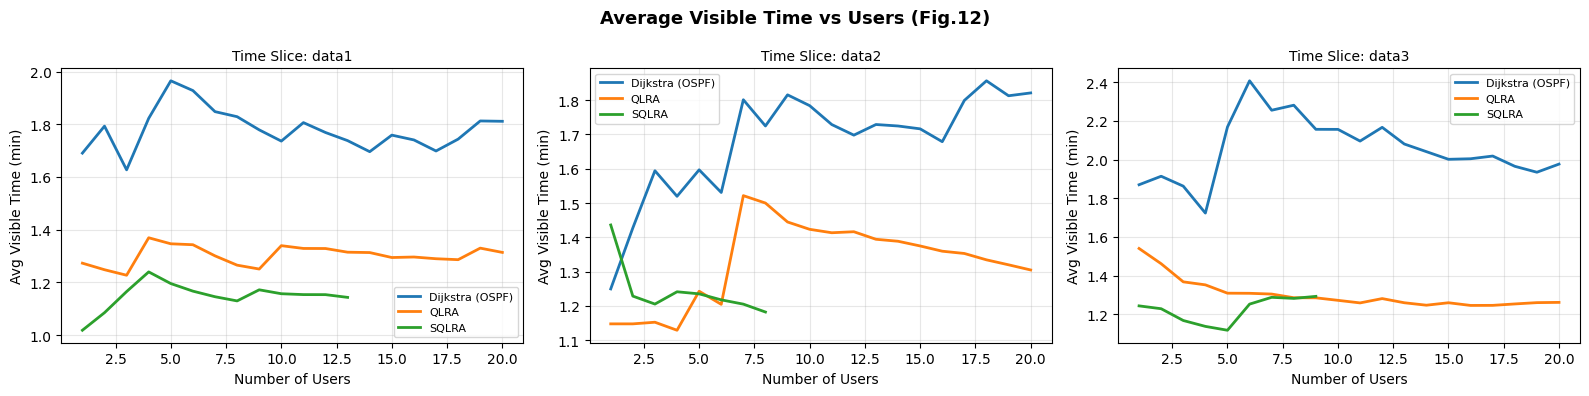

✅ All 4 comparison plots saved in satellite_results/


In [13]:
metrics  = ['throughput', 'delay', 'ber', 'vtime']
ylabels  = ['Avg Throughput (Mbps)', 'Avg Delay (ms)', 'Avg BER (×10⁻⁷)', 'Avg Visible Time (min)']
titles   = ['Average Throughput vs Users (Fig.9)',
            'Average Delay vs Users (Fig.10)',
            'Average Bit Error Rate vs Users (Fig.11)',
            'Average Visible Time vs Users (Fig.12)']
colors   = {'dijkstra':'#1f77b4', 'qlra':'#ff7f0e', 'sqlra':'#2ca02c'}
labels_d = {'dijkstra':'Dijkstra (OSPF)', 'qlra':'QLRA', 'sqlra':'SQLRA'}
slices   = list(all_stats.keys())

Path('satellite_results').mkdir(exist_ok=True)

for metric, ylabel, title in zip(metrics, ylabels, titles):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, sl in zip(axes, slices):
        ax.set_title(f'Time Slice: {sl}', fontsize=10)
        for alg in ['dijkstra','qlra','sqlra']:
            data = all_stats[sl][alg][metric]
            if data:
                cum_avg = [np.mean(data[:i+1]) for i in range(len(data))]
                ax.plot(range(1, len(cum_avg)+1), cum_avg,
                        color=colors[alg], label=labels_d[alg], linewidth=2)
        ax.set_xlabel('Number of Users'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'satellite_results/{metric}_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

print("✅ All 4 comparison plots saved in satellite_results/")

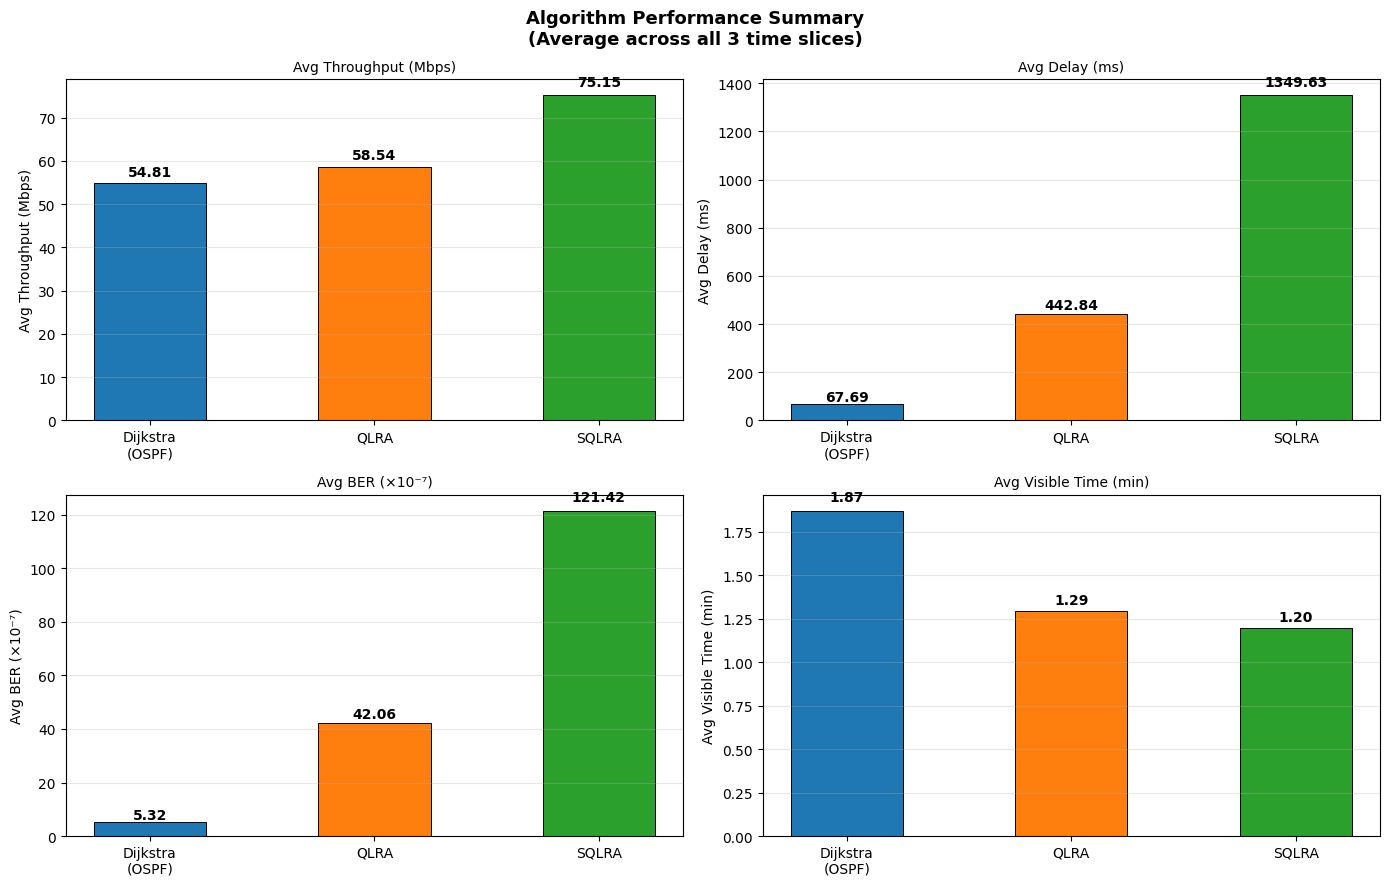

✅ Summary bar chart saved!


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Algorithm Performance Summary\n(Average across all 3 time slices)', fontsize=13, fontweight='bold')

for ax, metric, ylabel in zip(axes.flat, metrics, ylabels):
    alg_vals = []
    for alg in ['dijkstra','qlra','sqlra']:
        all_vals = []
        for sl in slices:
            all_vals.extend(all_stats[sl][alg][metric])
        alg_vals.append(np.mean(all_vals) if all_vals else 0)

    alg_names  = ['Dijkstra\n(OSPF)', 'QLRA', 'SQLRA']
    bar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    bars = ax.bar(alg_names, alg_vals, color=bar_colors, edgecolor='black', linewidth=0.7, width=0.5)
    for bar, val in zip(bars, alg_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(ylabel, fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('satellite_results/summary_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Summary bar chart saved!")